<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  str    
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  str    
 5   college_tier               100000 non-null  str    
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100000 non-nul

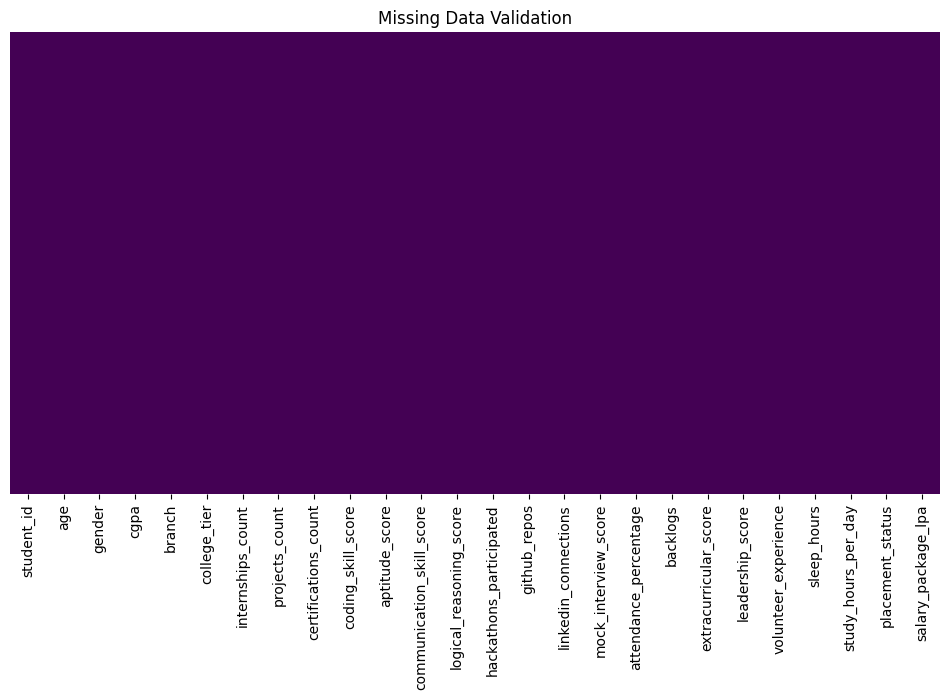

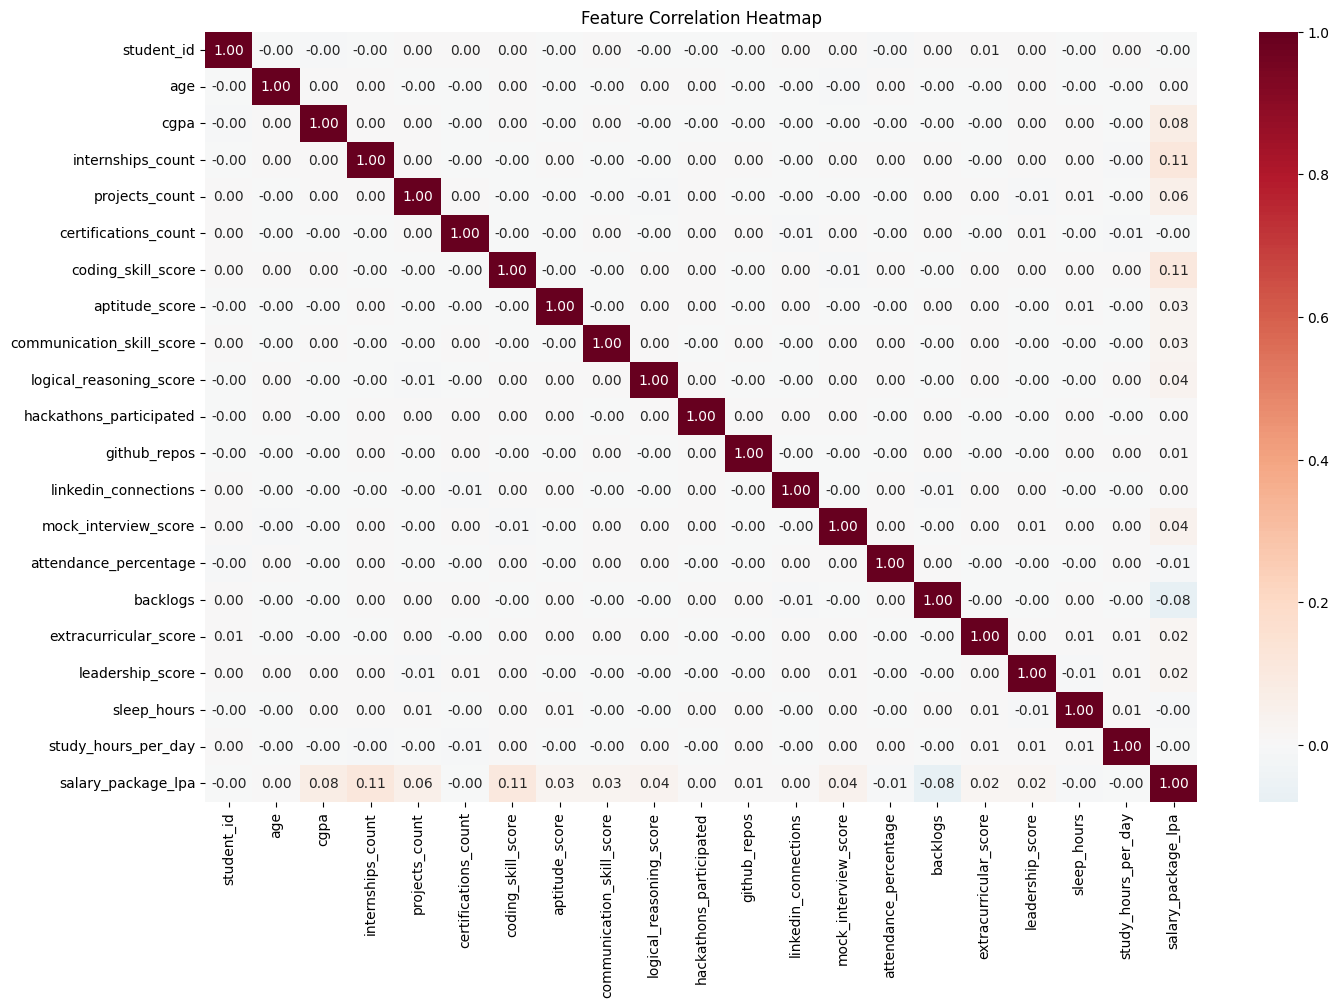

0.5686333333333333
Missclassified:12941
Random Forest Accuracy Score:0.5554
Missclassified: 13338


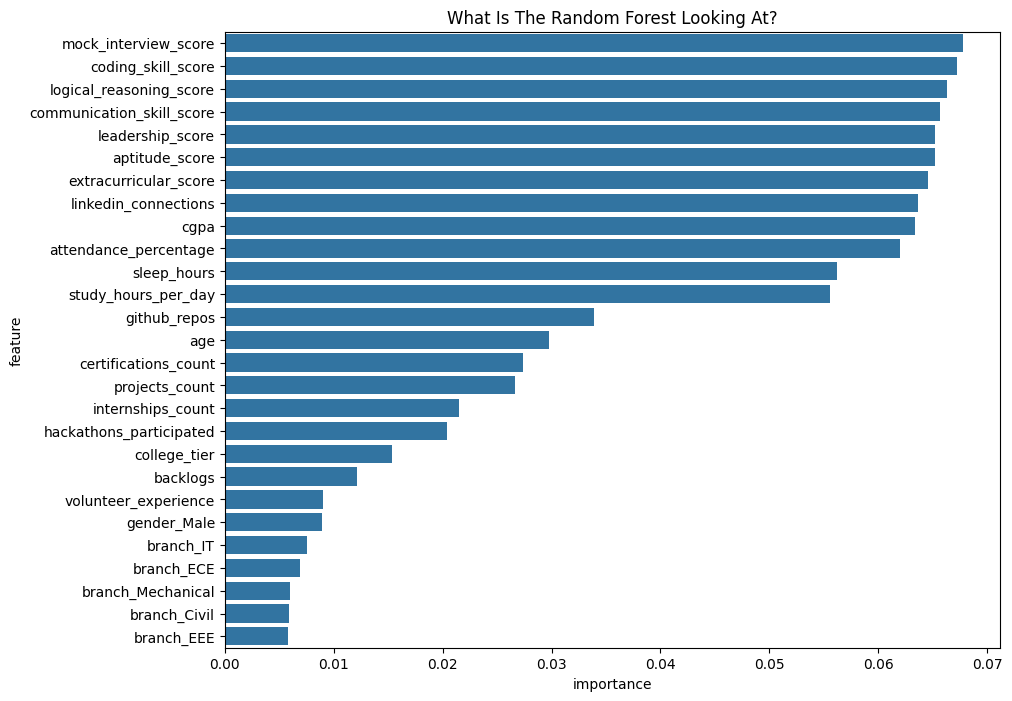

Tuned RF Accuracy 0.5627333333333333
Missclified: 13118
Top-5 Feature Accuracy: 0.5503333333333333
Salary Prediction R2 Score (Full Dataset): 0.04702496172950976
MAE: 6.40637372428967
Salary Range: 0.0 to 20.44
Average Salary: 7.252106100000001


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, mean_absolute_error ,r2_score
from sklearn.ensemble import RandomForestClassifier
file_path=r'C:\Users\samma\Downloads\student_placement_prediction_dataset_2026.csv'
df= pd.read_csv(file_path)
df.info(memory_usage="deep")
df.isnull().sum()
df.describe(include="all")
plt.figure(figsize=(12, 6)) # Makes the plot wider to fit all 26 labels
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Validation')
plt.show()
numeric_df=df.select_dtypes(include=[np.number])
plt.figure(figsize=(16,10))
correlation_matrix=numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="RdBu_r" ,center=0, fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()
df["college_tier"]=df["college_tier"].map({"Tier 1":1,"Tier 2":2,"Tier 3":3})
df["volunteer_experience"]=df["volunteer_experience"].map({"No":0 , "Yes":1})
newd=pd.get_dummies(df, columns=["branch","gender"],drop_first=True)
feat=list(set(newd.columns)-{"student_id","placement_status","salary_package_lpa"})
y=newd["placement_status"].values
x=newd[feat].values
train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=0.3,random_state=0)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
train_x_scaled=scaler.fit_transform(train_x)
test_x_scaled=scaler.transform(test_x)
Logistic=LogisticRegression(max_iter=100000)
Logistic.fit(train_x_scaled,train_y)
Logistic.coef_
Logistic.intercept_
prediction=Logistic.predict(test_x_scaled)
accuracy=accuracy_score(test_y,prediction)
print(accuracy)
print("Missclassified:%d" %(test_y != prediction).sum())
rf=RandomForestClassifier(n_estimators=100,random_state=0)
rf.fit(train_x_scaled,train_y)
rf_pred=rf.predict(test_x_scaled)
print(f"Random Forest Accuracy Score:{accuracy_score(test_y,rf_pred)}")
print("Missclassified: %d" %(test_y != rf_pred).sum())
importances = pd.DataFrame({'feature':feat,'importance':rf.feature_importances_})
importances=importances.sort_values(by='importance', ascending=False)
plt.figure(figsize=(10,8))
sns.barplot(x='importance',y='feature',data=importances)
plt.title("What Is The Random Forest Looking At?")
plt.show()
rf_tuned=RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=50,
    random_state=0
)
rf_tuned.fit(train_x_scaled,train_y)
tuned_pred=rf_tuned.predict(test_x_scaled)
print(f"Tuned RF Accuracy {accuracy_score(test_y,tuned_pred)}")
print("Missclified: %d" %(test_y != tuned_pred).sum())
top_feat = ['mock_interview_score', 'coding_skill_score', 'logical_reasoning_score', 'aptitude_score', 'communication_skill_score']
X_top = newd[top_feat].values
train_x_top, test_x_top, train_y_top, test_y_top = train_test_split(X_top, y, test_size=0.3, random_state=0)
scaler_top = StandardScaler()
train_x_top_scaled = scaler_top.fit_transform(train_x_top)
test_x_top_scaled = scaler_top.transform(test_x_top)
model_top = LogisticRegression()
model_top.fit(train_x_top_scaled, train_y_top)
print(f"Top-5 Feature Accuracy: {model_top.score(test_x_top_scaled, test_y_top)}")
y_all_salary=newd["salary_package_lpa"].values
x_all_salary=newd[feat].values
tr_x,te_x,tr_y,te_y=train_test_split(x_all_salary,y_all_salary,test_size=0.3,random_state=0)
scaler_all=StandardScaler()
tr_x_scaled=scaler_all.fit_transform(tr_x)
te_x_scaled=scaler_all.transform(te_x)
lin_model=LinearRegression()
lin_model.fit(tr_x_scaled,tr_y)
print(f"Salary Prediction R2 Score (Full Dataset): {lin_model.score(te_x_scaled, te_y)}")
from sklearn.metrics import mean_absolute_error
print(f"MAE: {mean_absolute_error(te_y, lin_model.predict(te_x_scaled))}")
print(f"Salary Range: {df['salary_package_lpa'].min()} to {df['salary_package_lpa'].max()}")
print(f"Average Salary: {df['salary_package_lpa'].mean()}")